In [64]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [65]:
import torch
from torch import nn
import sklearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

In [66]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [67]:
from sklearn.datasets import make_blobs

In [68]:
from numpy._core.defchararray import center
num_classes = 4
num_features = 2

X, y = make_blobs(n_samples=1000,
                  n_features=num_features,
                  centers=num_classes,
                  cluster_std=1.5,
                  random_state=42)

In [69]:
X = torch.tensor(X, dtype=torch.float32).to(device)
y = torch.tensor(y, dtype=torch.long).to(device)

In [70]:
X.shape, y.shape

(torch.Size([1000, 2]), torch.Size([1000]))

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

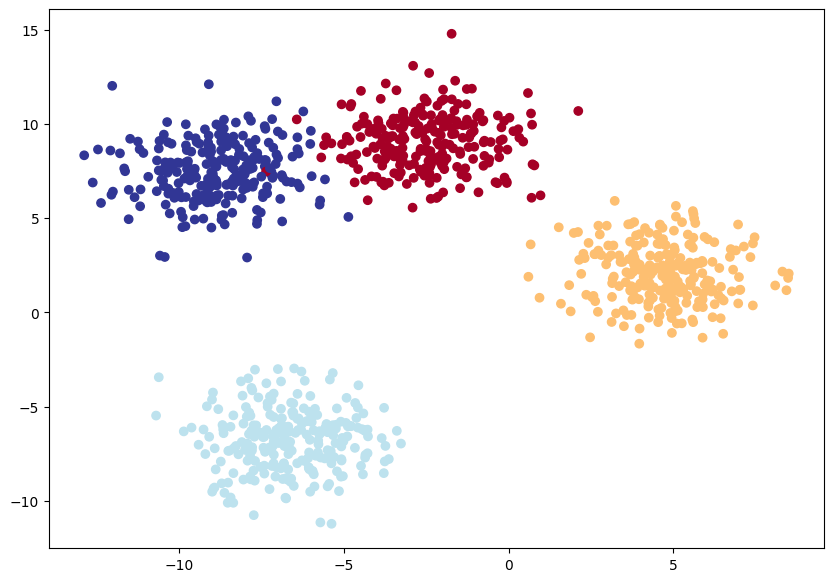

In [72]:
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

Look the above graph later, how to run that

In the below code, input features are similar to the number of features within each class and the output is similar to the number of classes

In [73]:
torch.manual_seed(42)

In [74]:
model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16,16),
    nn.ReLU(),
    nn.Linear(16,4)
).to(device)

In [75]:
list(model.parameters())

[Parameter containing:
 tensor([[ 0.5406,  0.5869],
         [-0.1657,  0.6496],
         [-0.1549,  0.1427],
         [-0.3443,  0.4153],
         [ 0.6233, -0.5188],
         [ 0.6146,  0.1323],
         [ 0.5224,  0.0958],
         [ 0.3410, -0.0998],
         [ 0.5451,  0.1045],
         [-0.3301,  0.1802],
         [-0.3258, -0.0829],
         [-0.2872,  0.4691],
         [-0.5582, -0.3260],
         [-0.1997, -0.4252],
         [ 0.0667, -0.6984],
         [ 0.6386, -0.6007]], requires_grad=True),
 Parameter containing:
 tensor([ 0.5459,  0.1177, -0.2296,  0.4370,  0.1102,  0.5713,  0.0773, -0.2230,
          0.1900, -0.1918,  0.2976,  0.6313,  0.4087, -0.3091,  0.4082,  0.1265],
        requires_grad=True),
 Parameter containing:
 tensor([[ 0.1270, -0.1524, -0.2475, -0.0966, -0.1918,  0.2051,  0.0720,  0.1036,
           0.0791, -0.0043,  0.1957, -0.1776,  0.0157, -0.1706,  0.0771, -0.0861],
         [ 0.0766, -0.0521,  0.2073, -0.1482, -0.1491, -0.1491,  0.2249,  0.0833,
      

In [76]:
torch.unique(y_train)

tensor([0, 1, 2, 3])

In [77]:
# Create a loss funtion for multi-class classification
loss_fn = nn.CrossEntropyLoss()

In [78]:
# Create an optimizer for multi-class classification
optimizer = torch.optim.Adam(lr=0.01, params=model.parameters())

In order to evaluate and train and test our model, we need to convert out model's outputs/logits to prediction probabilites and then to prediction labels.

Logits -> Pred Probs (use torch.softmax) -> Pred Labels (take the argmax of prediction probabilities)

In [79]:
for epoch in range(100):
  model.train()
  logits = model(X_train)
  y_pred = torch.argmax(logits, dim=1)
  loss = loss_fn(logits, y_train)
  accuracy = (y_pred == y_train).float().mean()
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 10 == 0:
    with torch.inference_mode():
      print(f'epoch: {epoch}, accuracy: {accuracy}, loss: {loss}')



epoch: 0, accuracy: 0.037142857909202576, loss: 1.5284544229507446
epoch: 10, accuracy: 0.9342857003211975, loss: 0.4421626925468445
epoch: 20, accuracy: 0.9842857122421265, loss: 0.13160072267055511
epoch: 30, accuracy: 0.9900000095367432, loss: 0.044643010944128036
epoch: 40, accuracy: 0.991428554058075, loss: 0.02834625542163849
epoch: 50, accuracy: 0.9928571581840515, loss: 0.02677171677350998
epoch: 60, accuracy: 0.9928571581840515, loss: 0.02596348337829113
epoch: 70, accuracy: 0.9928571581840515, loss: 0.02500777877867222
epoch: 80, accuracy: 0.9928571581840515, loss: 0.024115467444062233
epoch: 90, accuracy: 0.9928571581840515, loss: 0.023558886721730232


In [80]:
model.eval()
with torch.inference_mode():
  test_logits = model(X_test)
  y_test_pred = torch.argmax(test_logits, dim=1)
  test_accuracy = (y_test_pred == y_test).float().mean()
print(f'Test Accuracy: {test_accuracy}')

Test Accuracy: 0.9933333396911621


In [81]:
y_test_pred[:10], y_test[:10]

(tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0]),
 tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0]))

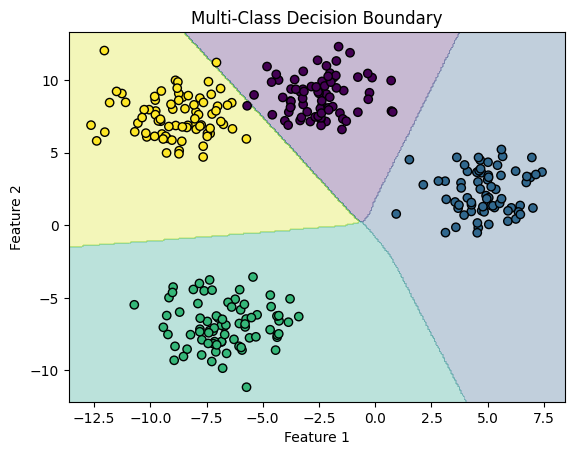

In [82]:
# ============================================================
# 12. VISUALIZE DECISION BOUNDARY
# ============================================================

model.eval()

X_plot = X_test.cpu()
y_plot = y_test.cpu()

x_min = X_plot[:, 0].min() - 1
x_max = X_plot[:, 0].max() + 1

y_min = X_plot[:, 1].min() - 1
y_max = X_plot[:, 1].max() + 1


xx, yy = torch.meshgrid(
    torch.linspace(x_min, x_max, 300),
    torch.linspace(y_min, y_max, 300),
    indexing="xy"
)

grid = torch.stack(
    [xx.flatten(), yy.flatten()],
    dim=1
).to(device)


with torch.no_grad():

    grid_logits = model(grid)

    grid_predictions = torch.argmax(
        grid_logits,
        dim=1
    )


grid_predictions = grid_predictions.cpu().reshape(
    xx.shape
)


plt.contourf(
    xx.numpy(),
    yy.numpy(),
    grid_predictions.numpy(),
    alpha=0.3
)

plt.scatter(
    X_plot[:, 0],
    X_plot[:, 1],
    c=y_plot,
    edgecolors="black"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Multi-Class Decision Boundary")

plt.show()


In [83]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test.cpu(),
        y_test_pred.cpu()
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        75
           1       1.00      1.00      1.00        69
           2       1.00      1.00      1.00        79
           3       0.99      0.99      0.99        77

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [84]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(
    y_test.cpu(),
    y_test_pred.cpu(),
    average="weighted"
)

recall = recall_score(
    y_test.cpu(),
    y_test_pred.cpu(),
    average="weighted"
)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.9933
Recall: 0.9933


In [85]:
!pip install torchmetrics

In [86]:
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall
)

accuracy = MulticlassAccuracy(num_classes=4)
precision = MulticlassPrecision(num_classes=4, average="macro")
recall = MulticlassRecall(num_classes=4, average="macro")

print("Accuracy:", accuracy(y_test_pred, y_test))
print("Precision:", precision(y_test_pred, y_test))
print("Recall:", recall(y_test_pred, y_test))

Accuracy: tensor(0.9934)
Precision: tensor(0.9934)
Recall: tensor(0.9934)


In [87]:
from torchmetrics.classification import MulticlassAUROC

roc_auc = MulticlassAUROC(num_classes=4, average="macro")

model.eval()

with torch.inference_mode():
    logits = model(X_test)
    y_test_probs = torch.softmax(logits, dim=1)

print("ROC-AUC:", roc_auc(y_test_probs, y_test))

ROC-AUC: tensor(1.0000)
